In [1]:
from scipy.interpolate import interp1d
from phase_II.fast_wigner_function.utils import *
import nifty.nifty.cl as ift

In [2]:
def interpolator(x_array, y_array):
    # if outside of bound, will be filled with 0's
    return interp1d(x_array, y_array, kind='cubic', bounds_error=False, fill_value=0)

def stress(xi, time, omega, supress_print=False):
    """

    :param xi:          The xi array in Fourier space. MUST BE IN DFT STANDARD ORDER.
    :param omega:       The frequency values at which xi is reported.  MUST BE IN DFT STANDARD ORDER.
    :param time:        The corresponding time samples.
    :param supress_print: If True, supress printing of the interpolated values.
    :return:
    """
    N = len(time)
    kappa = omega.copy()

    xi = interpolator(omega, xi)

    omega_cast, kappa_cast, time_cast = (omega[:, None], kappa[None, :], time[None, :])

    # --- compute target frequencies for Psi ---
    arg1_frequencies = 2*omega_cast - np.pi * kappa_cast
    arg2_frequencies = 0*omega_cast + np.pi * kappa_cast

    # print("arg1_frequencies: ", 2*omega - np.pi * kappa)
    # print("\tmapping to xi(): ", xi(2*omega - np.pi * kappa))
    # print("arg2_frequencies", np.pi * kappa)
    # print("\tmapping to xi(): ", xi(np.pi * kappa))

    arg1_idx_based = freq_to_index(arg1_frequencies, omegas=omega)
    arg2_idx_based = freq_to_index(arg2_frequencies, omegas=omega)

    # print("arg1 min/max:", arg1_frequencies.min(), arg1_frequencies.max())
    # print("arg2 min/max:", arg2_frequencies.min(), arg2_frequencies.max())

    Psi = xi(arg1_frequencies).conj() * xi(arg2_frequencies )
    # Psi = xi[arg1_idx_based].conj() * xi[arg2_idx_based]

    # print("Where is Psi first contribution non-zero?",np.where(xi(2*omega_cast - np.pi*kappa_cast).conj() != 0))
    # print("Where is Psi second contribution non-zero?",np.where(xi( 0*omega_cast + np.pi*kappa_cast ) != 0))
    # print("Where is Psi non-zero?",np.where(Psi != 0))

    Phi = np.fft.ifft(Psi, axis=1, norm='forward')  # leaving out the 1/N scaling to not bias: interpolator introduces extra entries (0's) for Nyquist twins, biasing the value of N

    E = np.exp(-2j * omega_cast * time_cast)

    S_mat = E * Phi
    if not supress_print:
        diagnostic = np.abs(np.mean(S_mat.imag))
        if diagnostic < 1e-10:
            print(f"\u2714 Mean imaginary part of stress field is smaller than 1e-10 threshold ({diagnostic}) ")
        else:
            raise_warning(f"Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 ({diagnostic}).")
    return S_mat, time, omega

In [3]:

L = 2
N = 2000
dx = L/N

x = ift.RGSpace(shape=(N,), distances=dx)
y = x.get_default_codomain()
t = np.linspace(0, L, N)

omega_nyquist = 1/(2*dx)
omega = mirror_negative_frequencies(y.get_unique_k_lengths(), unique_k_lengths=True, standard_order=False)
print("Omega nyquist: ", omega_nyquist)

Omega nyquist:  500.0


In [4]:
xi_tilde = xi_field(case=1, N=N, omegas=omega, peak_amplitude=1e6, peak_frequency=omega[80])
# xi_tilde = xi_field(case=4, N=N, use_complex=True, length=np.sqrt(L))


Constructing xi field for case 1: Spike

	f star:  -460.0  at index  80


In [5]:
xi_tilde_reordered = np.fft.ifftshift(xi_tilde)
omega_reordered = np.fft.ifftshift(omega)  # if you like, compare against k = np.fft.fftfreq(N, d=dx)
# print("index of spike after reordering: ",np.where(xi_tilde_reordered!=0))

In [6]:
S_mat, _, _ = stress(xi=xi_tilde_reordered, time=t, omega=omega_reordered)

/var/folders/6s/zt639pwd3kg46kcb8b3t121r0000gp/T/ipykernel_10159/1463051936.py:53: UserWarning: Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 (38972422.00400194).
  raise_warning(f"Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 ({diagnostic}).")


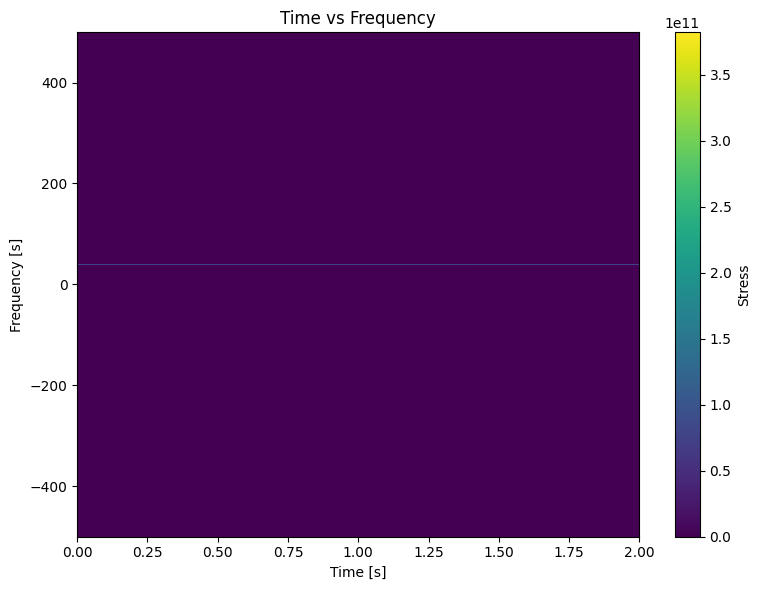

Mean and std:  174359553.08291158 8609845773.231365


In [7]:
visualize_stress(np.abs(S_mat), omega_reordered, t)
print("Mean and std: ", np.mean(S_mat.real), np.std(S_mat.real))

In [ ]:
# Average:

S_mats = []
for _ in range(100):
    xi_tilde_reordered = np.fft.ifftshift(xi_tilde)
    xi_tilde = xi_field(case=4, N=N, use_complex=True, length=np.sqrt(L), supress_print=True)
    S_mat, _, _ = stress(xi=xi_tilde_reordered, time=t, omega=omega_reordered, supress_print=True)
    S_mats.append(S_mat)



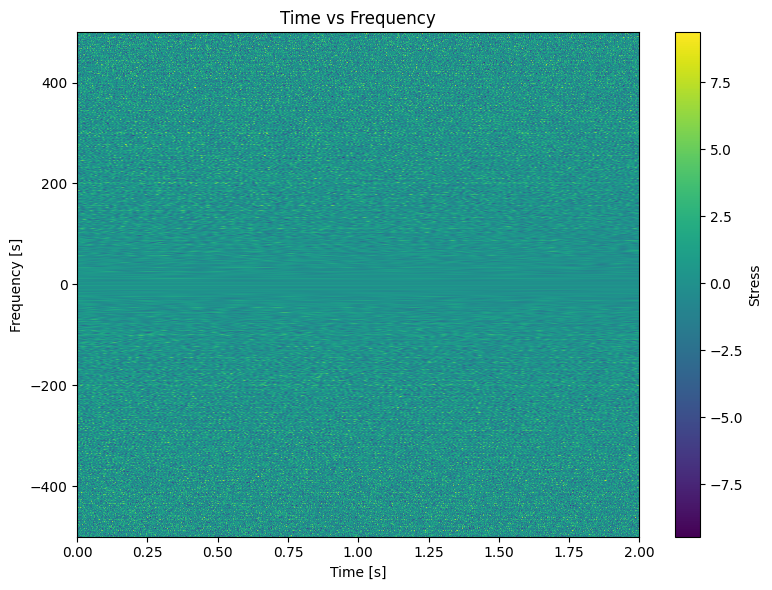

Mean and std:  0.19884666218301852 1.2847146555977582
Mean of std field (mean standard deviation accross samples)  14.669838665078931
imag:  -0.0003276011155397448


In [113]:
S_mat_average = np.mean(S_mats, axis=0)

visualize_stress(np.real(S_mat_average), omega_reordered, t)
print("Mean and std: ", np.mean(S_mat_average.real), np.std(S_mat_average.real))
print("Mean of std field (mean standard deviation accross samples) ", np.mean(np.std(S_mats, axis=0)))
print("imag: ", np.mean(S_mat_average.imag))

In [102]:
# Let's check out a Gaussian spike:
def gaussian_spike(N, k0, sigma=3, amp=1.0):
    k = np.arange(N)
    xi = amp * np.exp(-0.5 * ((k - k0) / sigma)**2)
    return xi

xi_gaussian = gaussian_spike(N, k0=0, sigma=5, amp=100)
xi_gaussian_reordered = np.fft.ifftshift(xi_gaussian)

stress_gaussian, _, _ = stress(xi=xi_gaussian_reordered, time=t, omega=omega_reordered)


/var/folders/6s/zt639pwd3kg46kcb8b3t121r0000gp/T/ipykernel_7587/1463051936.py:53: UserWarning: Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 (1.1996645281970164).
  raise_warning(f"Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 ({diagnostic}).")


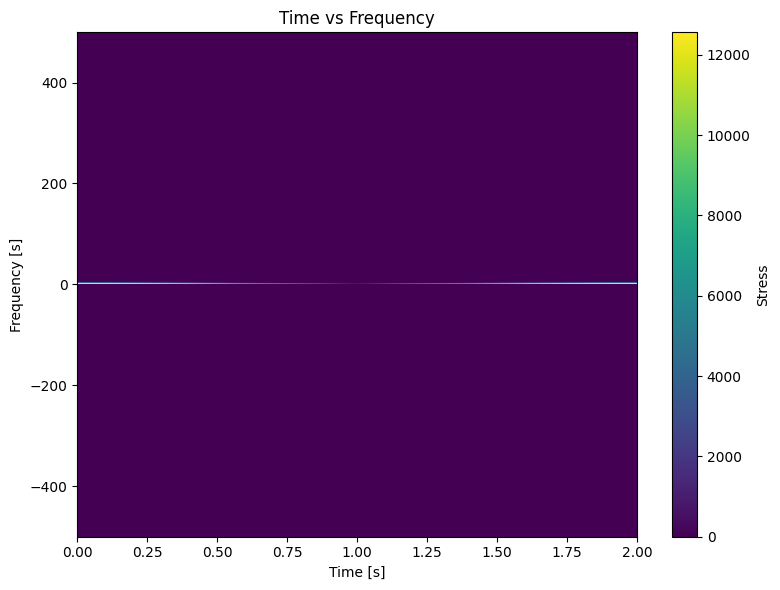

In [103]:
visualize_stress(np.abs(stress_gaussian), omega_reordered, t)

omega star is:  1.2822827157509358
Mean imag value:  -12367988.55715308
Mean real value:  -12367988.55715308


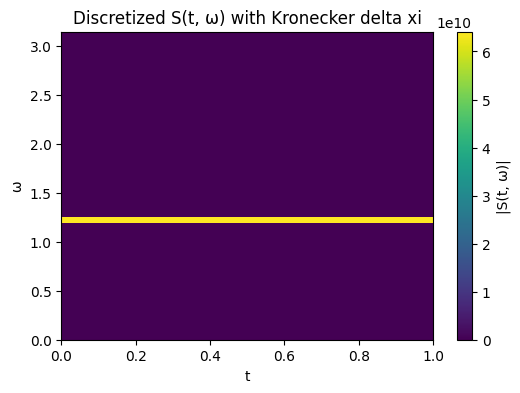

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_t = 100        # number of time points
N_k = 50         # number of kappa points
N_omega = 50     # number of omega points

t = np.linspace(0, 1, N_t)
kappa = np.linspace(0, np.pi, N_k)
omega = np.linspace(0, np.pi, N_omega)

k_star_idx = 20
a = 1e6          # amplitude
k_star = omega[k_star_idx] # spike location

print("omega star is: ", k_star)

# Discretized xi (Kronecker delta at k_star)
xi = np.zeros(N_k)
# find closest grid point to k_star/pi
idx_star = np.argmin(np.abs(kappa - k_star/np.pi))
xi[idx_star] = a

# Build Psi(omega, kappa)
Psi = np.zeros((N_omega, N_k), dtype=complex)
for i, w in enumerate(omega):
    for j, k in enumerate(kappa):
        # discrete analog of 2*w - pi*k
        k1 = 2*w - np.pi*k
        # find nearest index for xi(k1)
        idx_k1 = np.argmin(np.abs(kappa - k1/np.pi))
        if xi[j] != 0 and 0 <= idx_k1 < N_k:
            Psi[i,j] = np.conj(xi[idx_k1]) * xi[j]

# Compute S(t, omega) discretized
S = np.zeros((N_omega, N_t), dtype=complex)
dk = kappa[1] - kappa[0]
for i, w in enumerate(omega):
    S[i,:] = np.exp(-2j * w * t) * np.sum(Psi[i,:][:,None] * np.exp(2j * np.pi * kappa[:,None] * t), axis=0) * dk

# Plot magnitude
plt.figure(figsize=(6,4))
plt.imshow(np.abs(S), origin='lower', aspect='auto',
           extent=[t[0], t[-1], omega[0], omega[-1]])
plt.colorbar(label='|S(t, ω)|')
plt.xlabel('t')
plt.ylabel('ω')
plt.title('Discretized S(t, ω) with Kronecker delta xi')
plt.show()


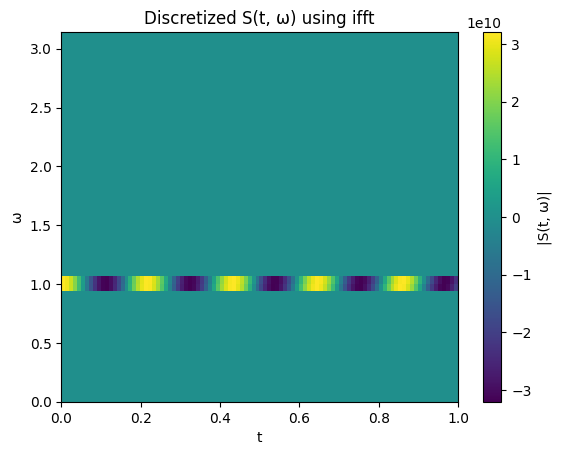

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_t = 100
N_k = 50
N_omega = 50

t = np.linspace(0, 1, N_t)
kappa = np.linspace(0, np.pi, N_k)
omega = np.linspace(0, np.pi, N_omega)

a = 1e6
k_star = np.pi/3

# Discretized xi
xi = np.zeros(N_k)
idx_star = np.argmin(np.abs(kappa - k_star/np.pi))
xi[idx_star] = a

# Build Psi(omega, kappa)
Psi = np.zeros((N_omega, N_k), dtype=complex)
for i, w in enumerate(omega):
    for j, k in enumerate(kappa):
        k1 = 2*w - np.pi*k
        idx_k1 = np.argmin(np.abs(kappa - k1/np.pi))
        if xi[j] != 0 and 0 <= idx_k1 < N_k:
            Psi[i,j] = np.conj(xi[idx_k1]) * xi[j]

# Compute S(t, omega) using FFT
dk = kappa[1] - kappa[0]

# Pad or truncate t to match N_k if necessary
# We'll assume N_t = N_k for simplicity here
S = np.exp(-2j * omega[:,None] * t[None,:]) * np.fft.ifft(Psi, axis=1, n=N_t) * N_k * dk

# Plot magnitude
plt.imshow(np.abs(S), origin='lower', aspect='auto',
           extent=[t[0], t[-1], omega[0], omega[-1]])
plt.colorbar(label='|S(t, ω)|')
plt.xlabel('t')
plt.ylabel('ω')
plt.title('Discretized S(t, ω) using ifft')
plt.show()
